# Exercise 2:  Proof of Work: Mining, Difficulty & Probability

**COMP842 Applied Blockchains and Cryptocurrencies**

- Name: Sokhour Lay
- Student ID: 25314544

## Library

In [10]:
import hashlib, time, statistics
import pandas as pd
import matplotlib.pyplot as plt

### 1. Proof-of-Work block and mining

In [11]:
def sha256(text):
    """Return the SHA-256 hash of a string (reused from Exercise 1)."""
    return hashlib.sha256(text.encode()).hexdigest()

class PoWBlock:
    def __init__(self, index, record, previous_hash):
        self.index = index
        self.record = record
        self.previous_hash = previous_hash
        self.nonce = 0            # the number we change to search for a valid hash
        self.hash = None

    def compute_hash(self):
        content = f"{self.index}{self.record}{self.previous_hash}{self.nonce}"
        return sha256(content)

    def mine(self, difficulty):
        """Increase the nonce until the hash starts with `difficulty` zeros.
        Returns the number of attempts made."""
        target = "0" * difficulty
        attempts = 0
        while True:
            self.hash = self.compute_hash()
            attempts += 1
            if self.hash.startswith(target):
                return attempts          # found a valid hash
            self.nonce += 1              # try the next nonce

#### Quick demo

In [12]:
demo = PoWBlock(1, "S2231 enrolled in English 101", "0")
attempts = demo.mine(3)
print("Hash    :", demo.hash)
print("Nonce   :", demo.nonce)
print("Attempts:", attempts)

Hash    : 000ea5b81df600730993d96baa8667a097b9a1b683a540a7fb87aac006425776
Nonce   : 1537
Attempts: 1538


**Explanation:** this reuses the SHA-256 helper from Exercise 1 and adds a nonce. Mining means repeatedly changing the nonce and re-hashing until the hash begins with the required number of zeros. The demo shows one block being mined at difficulty 3.

### 2. Running the experiment

In [13]:
def run_experiment(difficulties, blocks_per_difficulty):
    results = {}
    for d in difficulties:
        records = []
        for i in range(blocks_per_difficulty):
            block = PoWBlock(i, f"Academic record {i}", "0")
            start = time.perf_counter()
            attempts = block.mine(d)                  # number of hash calculations
            elapsed = time.perf_counter() - start     # mining time
            records.append({
                "block": i,
                "time": elapsed,        # mining time
                "hash": block.hash,     # the valid hash found
                "attempts": attempts,   # number of hash calculations
                "nonce": block.nonce,
            })
        results[d] = records
    return results

difficulties = [2, 3, 4, 5]
BLOCKS = 30
results = run_experiment(difficulties, BLOCKS)

# show one recorded block per difficulty: time, attempts, and the full valid hash
for d in difficulties:
    r = results[d][0]
    print(f"Difficulty {d}")
    print(f"  Mining time : {r['time']:.5f} s")
    print(f"  Attempts    : {r['attempts']}")
    print(f"  Valid hash  : {r['hash']}")
    print()

Difficulty 2
  Mining time : 0.00021 s
  Attempts    : 214
  Valid hash  : 00dd6b16eacba9316ffa6ba7e210448e370ab7e019ddc8c5c8257559a3381482

Difficulty 3
  Mining time : 0.03343 s
  Attempts    : 21815
  Valid hash  : 0004e8a7e813c4658b6688c7d8797f375f591830af6cecaf04eb4eafaac36925

Difficulty 4
  Mining time : 0.07143 s
  Attempts    : 55797
  Valid hash  : 0000f8a11457b3b055779cc1670b6957c81b4dc84cd57a0c11aa6a812509b934

Difficulty 5
  Mining time : 0.40870 s
  Attempts    : 330805
  Valid hash  : 000003a266871451231579871bff58c6b07c0a99c199c68b96bb6a4032189214



**Explanation:** for each of the 30 blocks at each difficulty, the experiment records the mining time, the valid hash that was found, and the number of hash calculations (attempts). The printout shows a sample block per difficulty, including its valid hash starting with the required zeros. Difficulty 5 is still slow, expect a minute or more.

### 3. Computing the metrics

In [14]:
def compute_metrics(results, difficulties):
    rows = []
    for d in difficulties:
        t = [r["time"] for r in results[d]]
        a = [r["attempts"] for r in results[d]]
        rows.append({
            "Difficulty": d,
            "Avg time (s)": round(statistics.mean(t), 5),
            "Min time (s)": round(min(t), 5),
            "Max time (s)": round(max(t), 5),
            "Std-dev time (s)": round(statistics.pstdev(t), 5),
            "Measured attempts (avg)": round(statistics.mean(a)),
            "Theoretical (16^d)": 16 ** d,
            "Throughput (H/s)": round(sum(a) / sum(t)),
        })
    return rows

### 4. Results table

In [15]:
df = pd.DataFrame(compute_metrics(results, difficulties))
df

,Difficulty,Avg time (s),Min time (s),Max time (s),Std-dev time (s),Measured attempts (avg),Theoretical (16^d),Throughput (H/s)
0,2,0.00029,0.00000,0.00111,0.00026,250,256,848575
1,3,0.00551,0.00000,0.03343,0.00655,4318,4096,783912
2,4,0.09358,0.00251,0.29638,0.08084,77125,65536,824164
3,5,1.60408,0.05310,5.78286,1.58430,1338793,1048576,834618


**Explanation**: this displays all the metrics in one table, so the measured attempts can be compared directly with the theoretical 16^difficulty.

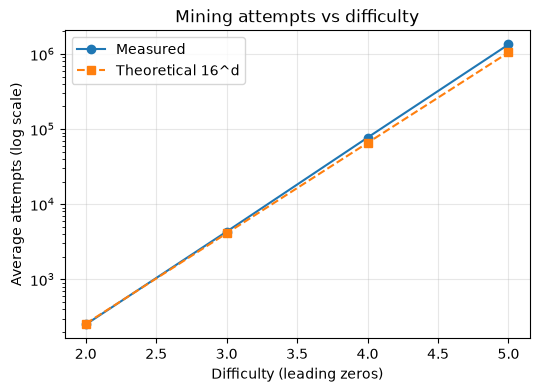

In [16]:
plt.figure(figsize=(6,4))
plt.plot(df["Difficulty"], df["Measured attempts (avg)"], "o-", label="Measured")
plt.plot(df["Difficulty"], df["Theoretical (16^d)"], "s--", label="Theoretical 16^d")
plt.yscale("log")                            # log scale: exponential growth becomes a straight line
plt.xlabel("Difficulty (leading zeros)")
plt.ylabel("Average attempts (log scale)")
plt.title("Mining attempts vs difficulty")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

The graph plots the average number of attempts against difficulty using a logarithmic vertical axis. Because both the measured and theoretical lines appear almost straight on this scale, the growth is exponential rather than linear: each additional leading zero multiplies the required attempts by roughly 16. The measured results follow the theoretical 16^difficulty line very closely, which confirms that mining behaves as a random search for a valid hash. The small gap between the two lines shows that the measured effort is slightly higher than the theoretical average, which is expected from natural variation between mining runs.

### 5. Interpretation

The results show that both the number of attempts and the average mining time increase sharply as difficulty rises. Each extra leading zero multiplies the required work by about 16, so the effort grows from roughly 250 attempts at difficulty 2 to about 1338793 attempts at difficulty 5. The measured attempts stay close to the theoretical value of 16^difficulty, which confirms that mining is essentially a random search for a valid hash. The throughput remains roughly constant at about 783912 to 848575 hashes per second across all difficulties, because each individual hash takes the same time to compute; what changes is how many hashes are needed.